In [ ]:
# Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE

In [ ]:
# Step 2: Load Dataset
data = pd.read_csv("/content/UCI_Credit_Card.csv")
data.head()


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [ ]:
# Step 3: Explore Data
print("\n--- Dataset Info ---")
print(data.info())

print("\n--- Missing Values ---")
print(data.isnull().sum())

print("\n--- Descriptive Statistics ---")
print(data.describe())



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2

In [ ]:
# Step 4: Define Features and Target
X = data.drop(['ID', 'default.payment.next.month'], axis=1)
y = data['default.payment.next.month']



--- Class Distribution ---
default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64


/tmp/ipython-input-1412398998.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


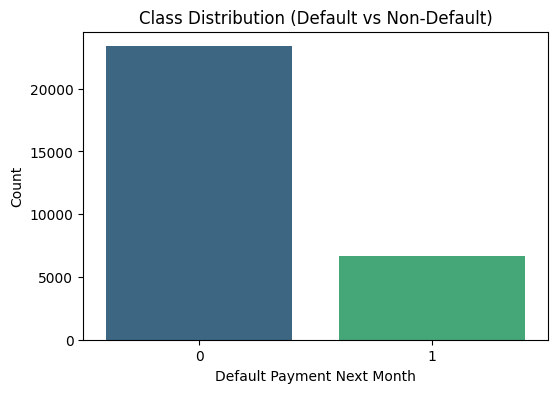

Imbalance Ratio (Default / Non-Default): 0.2840


In [ ]:
# Step 5: Check for class imbalance
class_counts = y.value_counts()
print("\n--- Class Distribution ---")
print(class_counts)

plt.figure(figsize=(6,4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Class Distribution (Default vs Non-Default)")
plt.xlabel("Default Payment Next Month")
plt.ylabel("Count")
plt.show()

ratio = class_counts[1] / class_counts[0]
print(f"Imbalance Ratio (Default / Non-Default): {ratio:.4f}")


In [ ]:
# Step 6: Split before SMOTE to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Before SMOTE:")
print(y_train.value_counts())


Before SMOTE:
default.payment.next.month
0    18691
1     5309
Name: count, dtype: int64


After SMOTE:
default.payment.next.month
0    18691
1    18691
Name: count, dtype: int64


/tmp/ipython-input-230723776.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_resampled, palette="mako")


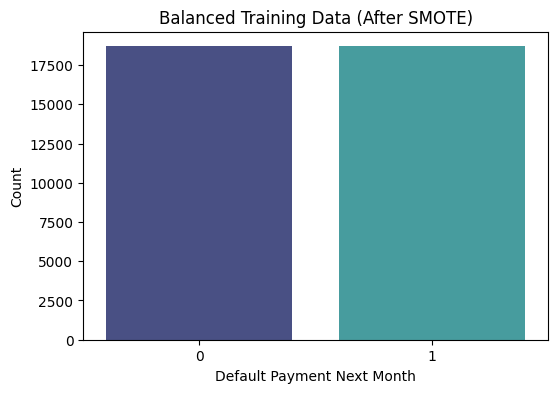

In [ ]:
# Step 7: Apply SMOTE (Balancing the training set)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(y_train_resampled.value_counts())

# Visualize balanced data
plt.figure(figsize=(6,4))
sns.countplot(x=y_train_resampled, palette="mako")
plt.title("Balanced Training Data (After SMOTE)")
plt.xlabel("Default Payment Next Month")
plt.ylabel("Count")
plt.show()


In [ ]:
# Step 8: Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# Step 9: Build Model
model = Sequential([
    Dense(256, activation='relu', input_dim=X_train_scaled.shape[1]),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary output
])

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,361 (185.00 KB)

 Trainable params: 47,361 (185.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Step 10: Train Model
history = model.fit(
    X_train_scaled, y_train_resampled,
    validation_split=0.2,
    epochs=50,
    batch_size=128,
    verbose=1
)


Epoch 1/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7048 - loss: 0.5941 - val_accuracy: 0.6715 - val_loss: 0.6036
Epoch 2/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7471 - loss: 0.5418 - val_accuracy: 0.6552 - val_loss: 0.6165
Epoch 3/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7463 - loss: 0.5403 - val_accuracy: 0.6598 - val_loss: 0.5977
Epoch 4/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7497 - loss: 0.5295 - val_accuracy: 0.6325 - val_loss: 0.6509
Epoch 5/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7523 - loss: 0.5243 - val_accuracy: 0.6307 - val_loss: 0.6516
Epoch 6/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7566 - loss: 0.5185 - val_accuracy: 0.6424 - val_loss: 0.6536
Epoch 7/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7603 - loss: 0.5155 - val_accuracy: 0.6497 - val_loss: 0.6363
Epoch 8/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7565 - loss: 0.5125 - val_accuracy: 0.

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      4673
           1       0.55      0.46      0.50      1327

    accuracy                           0.80      6000
   macro avg       0.70      0.68      0.69      6000
weighted avg       0.79      0.80      0.79      6000


--- Confusion Matrix ---


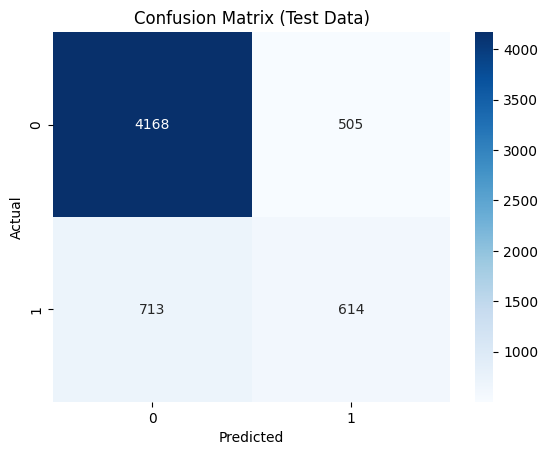

Test Accuracy: 0.7970


In [ ]:
# Step 11: Evaluate Model
y_pred = (model.predict(X_test_scaled) > 0.5).astype(int)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Test Data)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")


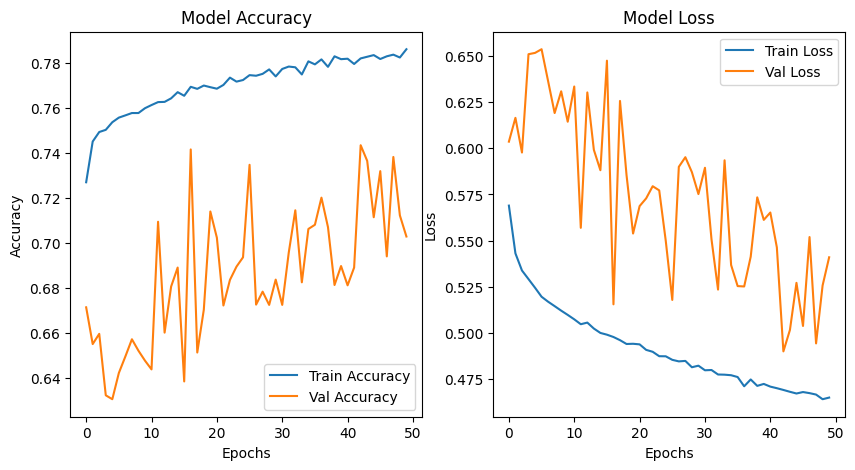

In [ ]:
# Step 12: Plot Training Curves
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()
